# 02 — Modelado

Entrenamiento y evaluación de modelos de clasificación multiclase ordinal para predecir el **tier de sala** de artistas de rap/urbano en España.

**Variable objetivo**: `nivel` → {1: bajo, 2: medio, 3: alto}  
**Tamaño del dataset**: 125 artistas  
**Clases**: bajo (48), medio (45), alto (32)

## Modelos evaluados

| Modelo | Modo features | Justificación |
|--------|--------------|---------------|
| Dummy (most_frequent) | — | Baseline mínimo |
| Dummy (stratified) | — | Baseline aleatorio estratificado |
| Regresión Logística | lineal (21 feat, RobustScaler) | Interpretable, bueno para clase ordinal |
| SVM (RBF) | lineal (21 feat, RobustScaler) | Kernel no lineal, robusto con escalado |
| Random Forest | arbol (26 feat, sin escalar) | Ensemble robusto, feature importance |
| XGBoost | arbol (26 feat, sin escalar) | Gradient boosting, suele ganar en tabular |

## Estrategia de validación

- **StratifiedKFold k=5**: garantiza representación proporcional de las 3 clases en cada fold. Adecuado para n=125 (25 muestras por fold).
- **Métricas**: accuracy + F1 macro (trata igual las 3 clases independientemente del tamaño)
- **`class_weight='balanced'`** en modelos que lo admiten: compensa el desbalanceo (alto=32 vs bajo=48)
- **Semilla fija** (`random_state=42`) para reproducibilidad

## 1. Setup

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from src.features.preprocess import cargar_datos

# Carpeta de figuras — se crea si no existe
FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

SEED    = 42
CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = ['accuracy', 'f1_macro']

LABEL_MAP = {1: 'bajo', 2: 'medio', 3: 'alto'}
CLASES    = ['bajo', 'medio', 'alto']

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Setup OK')

Setup OK


## 2. Cargar datos

In [2]:
X_arbol,  y, feat_arbol  = cargar_datos(modo='arbol')
X_lineal, _, feat_lineal = cargar_datos(modo='lineal')

print(f'X_arbol : {X_arbol.shape}   ({len(feat_arbol)} features, sin escalar)')
print(f'X_lineal: {X_lineal.shape}  ({len(feat_lineal)} features, RobustScaler)')
print(f'y       : {y.shape}')
print(f'\nDistribución del target:')
print(y.map(LABEL_MAP).value_counts().reindex(CLASES))

X_arbol : (125, 26)   (26 features, sin escalar)
X_lineal: (125, 21)  (21 features, RobustScaler)
y       : (125,)

Distribución del target:
target
bajo     48
medio    45
alto     32
Name: count, dtype: int64


## 3. Función de evaluación

Encapsula la validación cruzada y devuelve un resumen de métricas.

In [3]:
def evaluar_modelo(nombre, modelo, X, y, cv=CV, scoring=SCORING):
    """Evalúa un modelo con CV estratificado. Devuelve dict de resultados."""
    res = cross_validate(modelo, X, y, cv=cv, scoring=scoring, return_train_score=False)
    acc_mean  = res['test_accuracy'].mean()
    acc_std   = res['test_accuracy'].std()
    f1_mean   = res['test_f1_macro'].mean()
    f1_std    = res['test_f1_macro'].std()
    print(f'{nombre:<30}  acc={acc_mean:.3f}±{acc_std:.3f}  f1_macro={f1_mean:.3f}±{f1_std:.3f}')
    return {
        'nombre': nombre,
        'acc_mean': acc_mean, 'acc_std': acc_std,
        'f1_mean':  f1_mean,  'f1_std':  f1_std,
    }

resultados = []
print(f'{"Modelo":<30}  {"Accuracy":>14}  {"F1 macro":>14}')
print('-' * 64)

Modelo                                Accuracy        F1 macro
----------------------------------------------------------------


## 4. Baselines

- **most_frequent**: siempre predice 'bajo' (clase mayoritaria). Accuracy = 48/125 = 0.384.
- **stratified**: predice aleatoriamente respetando la distribución de clases.

Todo modelo útil debe superar ambos baselines.

In [4]:
resultados.append(evaluar_modelo(
    'Dummy (most_frequent)',
    DummyClassifier(strategy='most_frequent', random_state=SEED),
    X_arbol, y
))
resultados.append(evaluar_modelo(
    'Dummy (stratified)',
    DummyClassifier(strategy='stratified', random_state=SEED),
    X_arbol, y
))

Dummy (most_frequent)           acc=0.384±0.020  f1_macro=0.185±0.007
Dummy (stratified)              acc=0.256±0.093  f1_macro=0.221±0.082


## 5. Regresión Logística

Modelo lineal interpretable. Usa `X_lineal` (21 features, RobustScaler aplicado en `preprocess.py`).
- `solver='lbfgs'`: maneja multiclase automáticamente desde scikit-learn 1.5 (parámetro `multi_class` eliminado).
- `class_weight='balanced'`: ajusta pesos inversamente proporcionales a la frecuencia de cada clase.

In [5]:
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED,
)
resultados.append(evaluar_modelo('Regresión Logística', lr, X_lineal, y))

Regresión Logística             acc=0.728±0.059  f1_macro=0.719±0.053


## 6. SVM con kernel RBF

Modelo de márgenes máximos con kernel radial. Sensible al escalado → usa `X_lineal`.
- `kernel='rbf'`: captura relaciones no lineales entre features.
- `class_weight='balanced'`: penaliza más los errores en clases minoritarias.

In [6]:
svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=SEED,
)
resultados.append(evaluar_modelo('SVM (RBF)', svm, X_lineal, y))

SVM (RBF)                       acc=0.712±0.059  f1_macro=0.698±0.059


## 7. Random Forest

Ensemble de árboles de decisión con bagging. Usa `X_arbol` (26 features, sin escalar).
- `n_estimators=300`: número de árboles. Más árboles = menos varianza, pero rendimiento marginal decreciente.
- `max_features='sqrt'`: en cada split considera √26 ≈ 5 features — reduce correlación entre árboles.
- `class_weight='balanced_subsample'`: pesos balanceados recalculados en cada subsample del bootstrap.

In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
)
resultados.append(evaluar_modelo('Random Forest', rf, X_arbol, y))

Random Forest                   acc=0.736±0.120  f1_macro=0.733±0.124


## 8. XGBoost

Gradient boosting con regularización. Suele dar los mejores resultados en datos tabulares.
- `objective='multi:softprob'`: clasificación multiclase con probabilidades por clase.
- `scale_pos_weight`: no aplica en multiclase — usamos `sample_weight` vía `fit_params` (ignorado en cross_validate simple). XGBoost es razonablemente robusto al desbalanceo leve.
- `eval_metric='mlogloss'`: función de pérdida multiclase logarítmica.
- XGBoost espera clases 0-indexed: convertimos y→{0,1,2}.

In [8]:
y_xgb = y - 1  # XGBoost necesita clases 0-indexed: {0=bajo, 1=medio, 2=alto}

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
    n_jobs=-1,
)
resultados.append(evaluar_modelo('XGBoost', xgb, X_arbol, y_xgb))

XGBoost                         acc=0.792±0.089  f1_macro=0.793±0.087


## 9. Tabla comparativa

In [9]:
df_res = pd.DataFrame(resultados)
df_res['acc_display'] = df_res.apply(lambda r: f"{r.acc_mean:.3f} ± {r.acc_std:.3f}", axis=1)
df_res['f1_display']  = df_res.apply(lambda r: f"{r.f1_mean:.3f} ± {r.f1_std:.3f}",  axis=1)

display_cols = ['nombre', 'acc_display', 'f1_display']
tabla = df_res[display_cols].rename(columns={
    'nombre': 'Modelo',
    'acc_display': 'Accuracy (CV5)',
    'f1_display': 'F1 macro (CV5)',
}).set_index('Modelo')

print('\nResultados — StratifiedKFold k=5')
print('=' * 55)
print(tabla.to_string())


Resultados — StratifiedKFold k=5
                      Accuracy (CV5) F1 macro (CV5)
Modelo                                             
Dummy (most_frequent)  0.384 ± 0.020  0.185 ± 0.007
Dummy (stratified)     0.256 ± 0.093  0.221 ± 0.082
Regresión Logística    0.728 ± 0.059  0.719 ± 0.053
SVM (RBF)              0.712 ± 0.059  0.698 ± 0.059
Random Forest          0.736 ± 0.120  0.733 ± 0.124
XGBoost                0.792 ± 0.089  0.793 ± 0.087


## 10. Visualización — Comparativa de modelos

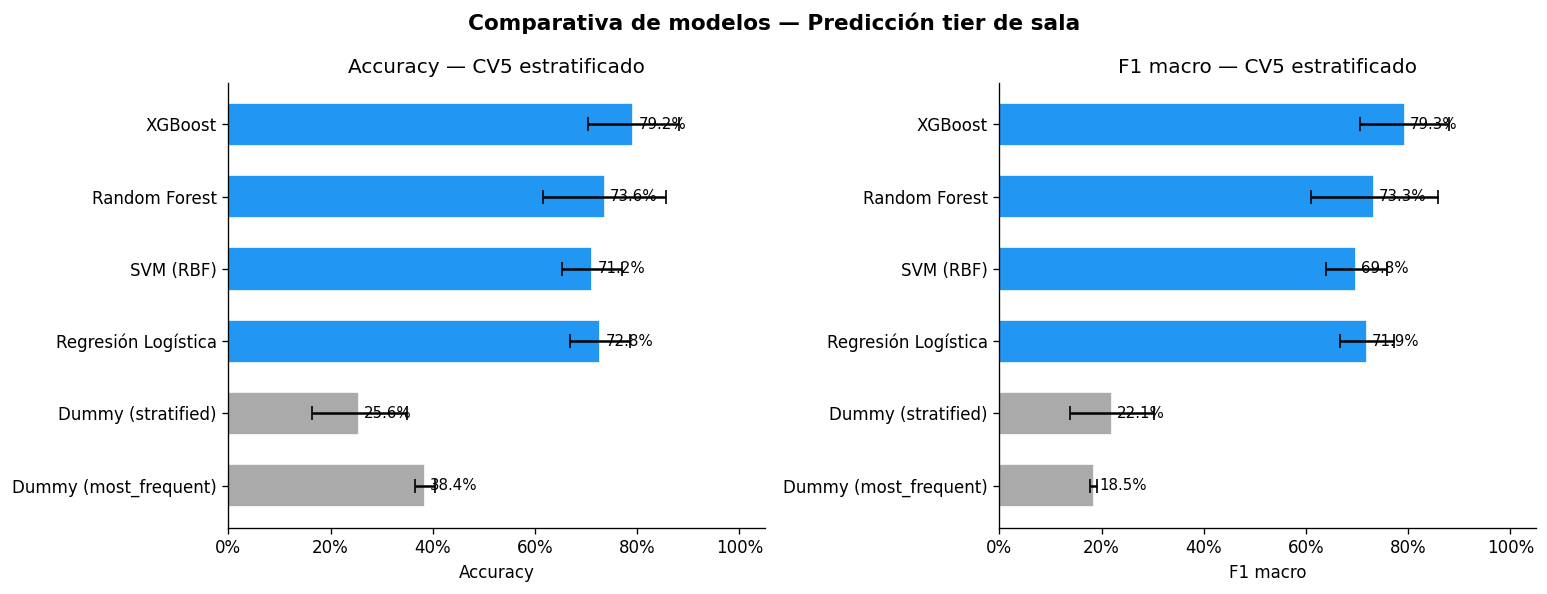

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
modelos_no_dummy = df_res[~df_res['nombre'].str.startswith('Dummy')]
modelos_todos    = df_res

for ax, metrica, label, df_plot in [
    (axes[0], 'acc',  'Accuracy',  modelos_todos),
    (axes[1], 'f1',   'F1 macro',  modelos_todos),
]:
    colores = ['#aaa' if 'Dummy' in n else '#2196F3' for n in df_plot['nombre']]
    bars = ax.barh(
        df_plot['nombre'],
        df_plot[f'{metrica}_mean'],
        xerr=df_plot[f'{metrica}_std'],
        color=colores,
        edgecolor='white',
        capsize=4,
        height=0.6,
    )
    ax.set_xlabel(label)
    ax.set_title(f'{label} — CV5 estratificado')
    ax.set_xlim(0, 1.05)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    for bar, val in zip(bars, df_plot[f'{metrica}_mean']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1%}',
                va='center', fontsize=9)

plt.suptitle('Comparativa de modelos — Predicción tier de sala', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/comparativa_modelos.png', bbox_inches='tight')
plt.show()

## 11. Matriz de confusión — predicciones out-of-fold

Usamos `cross_val_predict` para obtener predicciones **out-of-fold (OOF)**: cada artista es predicho por un modelo que NO lo ha visto durante el entrenamiento. Esto da una estimación honesta del comportamiento real del modelo, equivalente a las métricas de CV.

> No se usa train/test split clásico porque con n=125 un hold-out del 20% dejaría solo ~25 artistas de test — demasiado poco para estimar métricas fiables. El CV estratificado k=5 es la estrategia estándar para datasets pequeños.

In [11]:
mejor = df_res.loc[df_res['f1_mean'].idxmax(), 'nombre']
print(f'Mejor modelo: {mejor}')

# Predicciones OOF: cada artista predicho por un modelo que no lo vio en train
if mejor == 'XGBoost':
    y_oof = cross_val_predict(xgb, X_arbol, y_xgb, cv=CV)
    y_true_display = pd.Series(y_xgb.values).map({0: 'bajo', 1: 'medio', 2: 'alto'})
    y_pred_display = pd.Series(y_oof).map({0: 'bajo', 1: 'medio', 2: 'alto'})
elif mejor in ('Regresión Logística', 'SVM (RBF)'):
    y_oof = cross_val_predict(lr if mejor == 'Regresión Logística' else svm, X_lineal, y, cv=CV)
    y_true_display = pd.Series(y.values).map(LABEL_MAP)
    y_pred_display = pd.Series(y_oof).map(LABEL_MAP)
else:
    y_oof = cross_val_predict(rf, X_arbol, y, cv=CV)
    y_true_display = pd.Series(y.values).map(LABEL_MAP)
    y_pred_display = pd.Series(y_oof).map(LABEL_MAP)

print('\nClassification report — predicciones out-of-fold (CV):')
print(classification_report(y_true_display, y_pred_display, labels=CLASES))

Mejor modelo: XGBoost

Classification report — predicciones out-of-fold (CV):
              precision    recall  f1-score   support

        bajo       0.85      0.85      0.85        48
       medio       0.72      0.73      0.73        45
        alto       0.81      0.78      0.79        32

    accuracy                           0.79       125
   macro avg       0.79      0.79      0.79       125
weighted avg       0.79      0.79      0.79       125



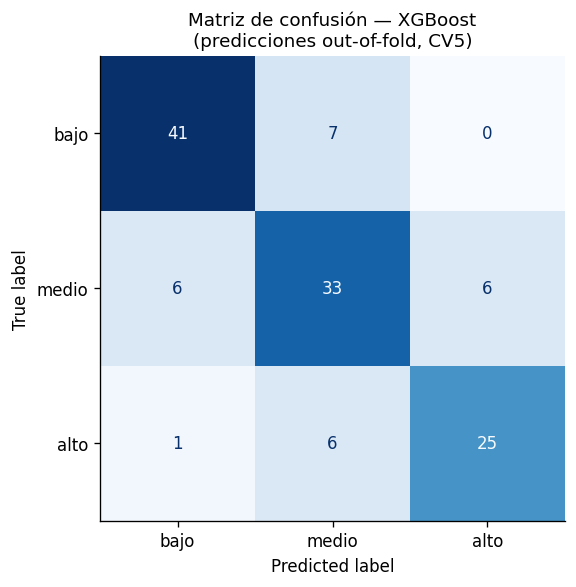

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true_display, y_pred_display, labels=CLASES)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusión — {mejor}\n(predicciones out-of-fold, CV5)', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', bbox_inches='tight')
plt.show()

## 12. Feature importance

### 12.1 Random Forest — Mean Decrease in Impurity (MDI)

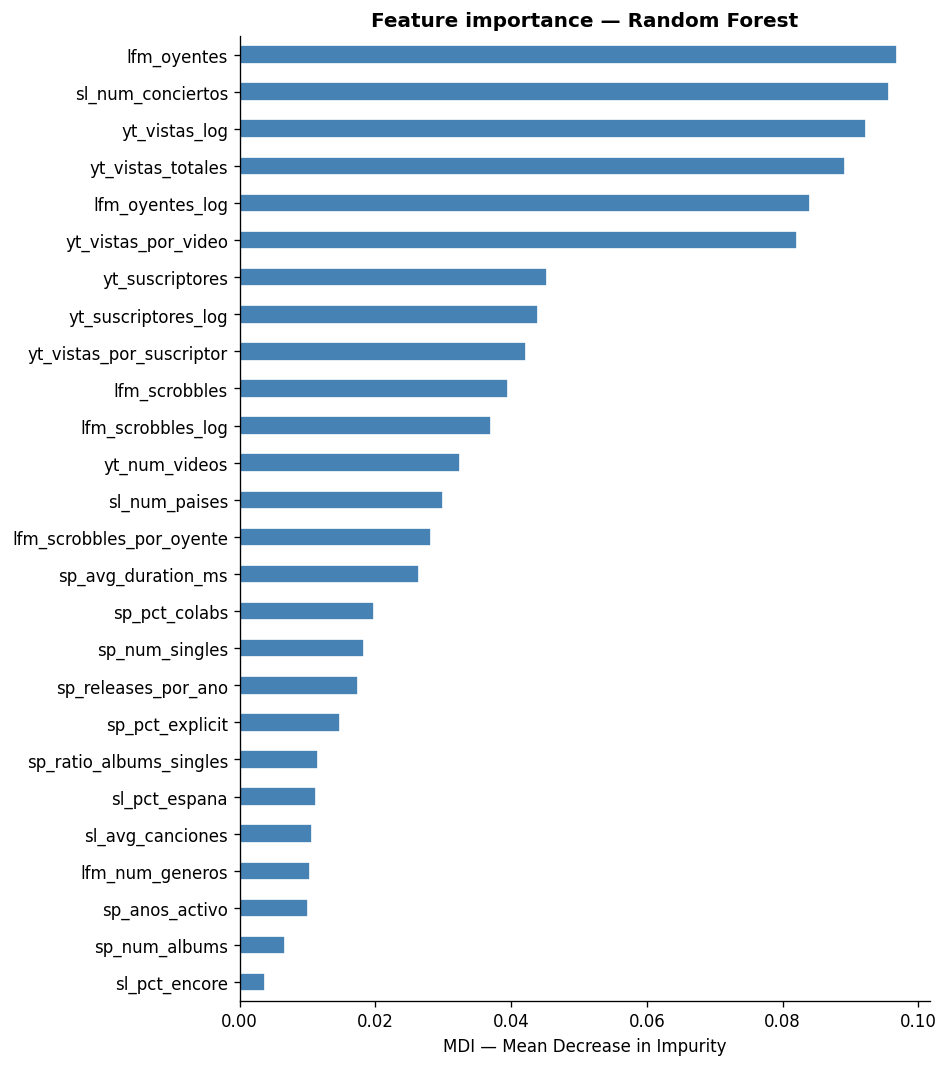

In [13]:
rf.fit(X_arbol, y)
importancias_rf = pd.Series(rf.feature_importances_, index=feat_arbol).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
importancias_rf.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('MDI — Mean Decrease in Impurity')
ax.set_title('Feature importance — Random Forest', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_rf.png', bbox_inches='tight')
plt.show()

### 12.2 XGBoost — Gain

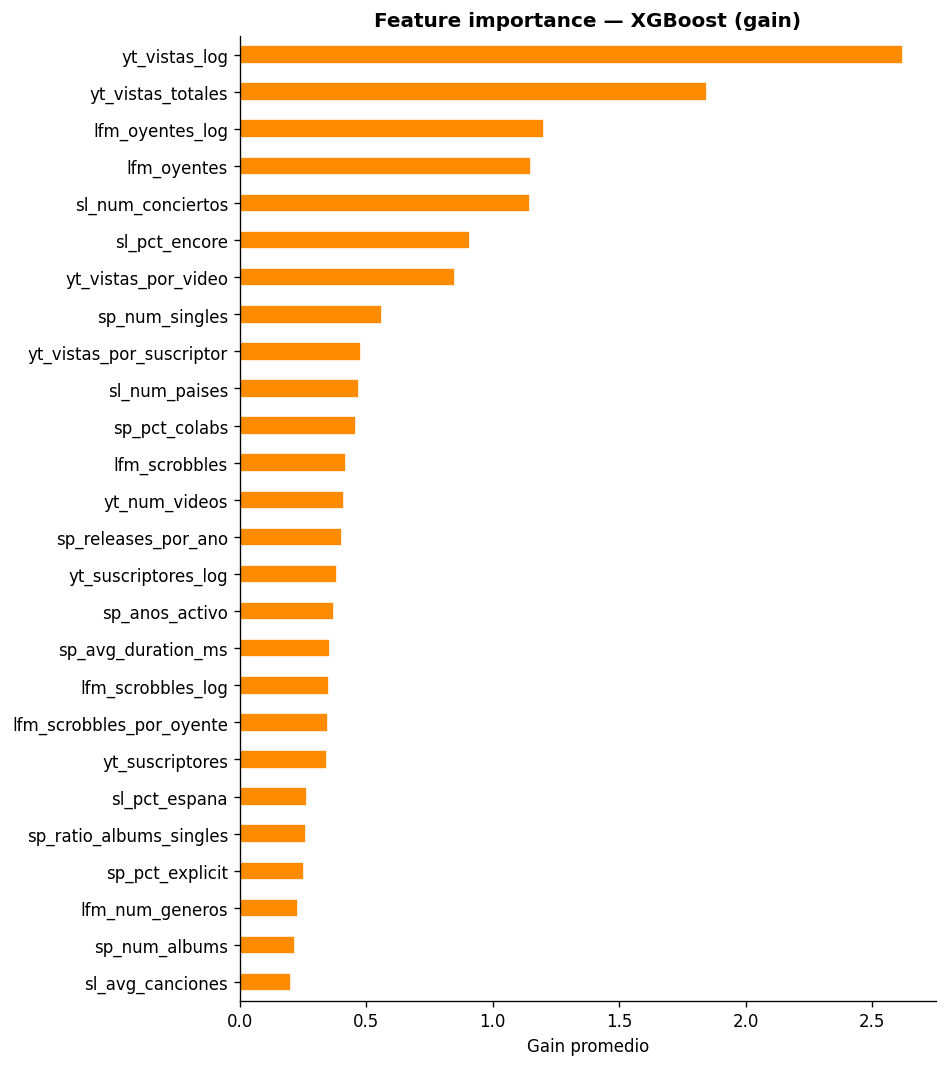

In [14]:
xgb.fit(X_arbol, y_xgb)
importancias_xgb = pd.Series(
    xgb.get_booster().get_score(importance_type='gain'),
    name='gain'
).reindex(feat_arbol).fillna(0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
importancias_xgb.plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Gain promedio')
ax.set_title('Feature importance — XGBoost (gain)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_xgb.png', bbox_inches='tight')
plt.show()

### 12.3 Top-10 features — RF vs XGBoost

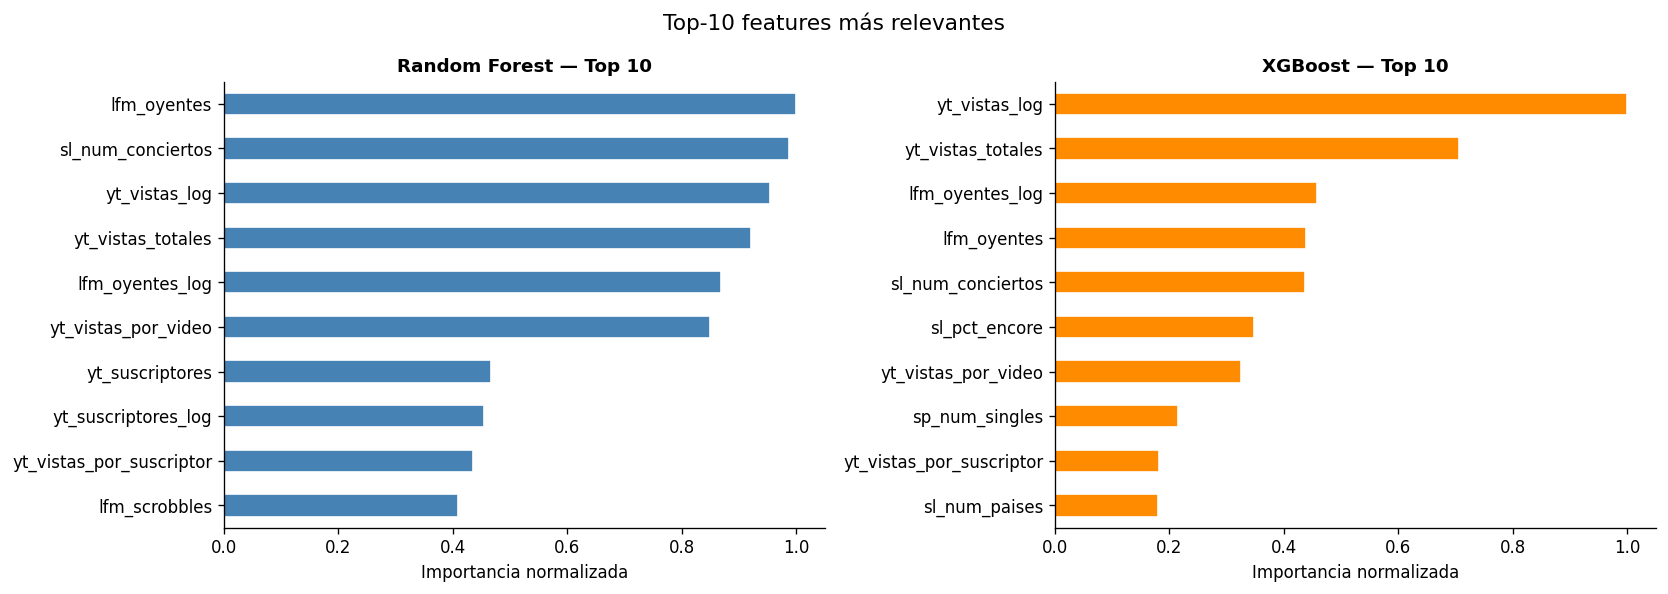

In [15]:
top_n = 10
rf_top  = importancias_rf.head(top_n)
xgb_top = importancias_xgb.head(top_n)

# Normalizar a escala 0-1 para comparación visual
rf_norm  = rf_top  / rf_top.max()
xgb_norm = xgb_top / xgb_top.max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, importancia, titulo, color in [
    (axes[0], rf_norm,  'Random Forest — Top 10', 'steelblue'),
    (axes[1], xgb_norm, 'XGBoost — Top 10',       'darkorange'),
]:
    importancia.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.invert_yaxis()
    ax.set_xlabel('Importancia normalizada')
    ax.set_title(titulo, fontsize=11, fontweight='bold')

plt.suptitle('Top-10 features más relevantes', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_top10.png', bbox_inches='tight')
plt.show()

## 13. Análisis de errores — ¿Dónde falla el mejor modelo?

Analizamos los artistas que el modelo clasifica incorrectamente en CV para entender si hay patrones sistemáticos.

In [16]:
df_raw = pd.read_csv('../data/processed/artist_features.csv')

# Reutilizar y_oof calculado en la sección 11 — mismas predicciones OOF
errores = df_raw[['nombre_buscado', 'nivel']].copy()
errores['pred_cv'] = y_pred_display.values
errores['correcto'] = errores['nivel'] == errores['pred_cv']

print(f'Artistas mal clasificados en CV ({mejor}): {(~errores.correcto).sum()} / {len(errores)}')
print(f'Accuracy CV estimada: {errores.correcto.mean():.1%}')
print()
print('Artistas con error de clasificación:')
print(errores[~errores.correcto][['nombre_buscado', 'nivel', 'pred_cv']].to_string(index=False))

Artistas mal clasificados en CV (XGBoost): 26 / 125
Accuracy CV estimada: 79.2%

Artistas con error de clasificación:
  nombre_buscado nivel pred_cv
          Tarchi  bajo   medio
            Guxo medio    bajo
ladiferencia2006 medio    bajo
           Ébano medio    bajo
          yyy891  bajo   medio
        Israel B medio    alto
        Choclock  alto   medio
      WEST DUBAI medio    bajo
     Kinder Malo  bajo   medio
       LaBlackie  alto   medio
       Oddliquor medio    bajo
           Rojuu medio    alto
            Hoke medio    alto
      Sara Socas  alto   medio
           MARCE  bajo   medio
    Shoda Monkas  bajo   medio
       vatocholo  alto    bajo
      Raul Clyde  alto   medio
        Gloosito medio    alto
            mvrk  alto   medio
        Munic HB  bajo   medio
      roomtrash6  bajo   medio
       nusar3000 medio    alto
        Lucho RK  alto   medio
         8belial medio    alto
        Kristina medio    bajo


In [17]:
# Tipos de error: ¿confunde bajo-medio o medio-alto?
errores_solo = errores[~errores.correcto].copy()
errores_solo['par_error'] = errores_solo['nivel'] + ' → ' + errores_solo['pred_cv']
print('Pares de error más frecuentes:')
print(errores_solo['par_error'].value_counts().to_string())

Pares de error más frecuentes:
par_error
bajo → medio    7
medio → bajo    6
medio → alto    6
alto → medio    6
alto → bajo     1


## 14. Conclusiones

### Resultados (StratifiedKFold k=5)

| Modelo | Accuracy | F1 macro |
|--------|----------|----------|
| Dummy most_frequent | 0.384 ± 0.020 | 0.185 ± 0.007 |
| Dummy stratified | 0.256 ± 0.093 | 0.221 ± 0.082 |
| Regresión Logística | 0.728 ± 0.059 | 0.719 ± 0.053 |
| SVM (RBF) | 0.712 ± 0.059 | 0.698 ± 0.059 |
| Random Forest | 0.736 ± 0.120 | 0.733 ± 0.124 |
| **XGBoost** | **0.792 ± 0.089** | **0.793 ± 0.087** |

**XGBoost es el mejor modelo**, con ~79% de accuracy y F1 macro — 41 puntos por encima del baseline más fuerte (most_frequent, 38.4%).

### Interpretación de resultados

- Todos los modelos superan claramente los baselines, lo que confirma que las features recogidas (audiencia digital, actividad en directo, discografía) tienen poder predictivo real sobre el tier de sala.
- Los modelos lineales (LR, SVM) son sorprendentemente competitivos pese a usar solo 21 features escaladas, lo que sugiere que la relación entre las features log-transformadas y el target es aproximadamente lineal.
- Random Forest tiene más varianza (±0.120) que XGBoost (±0.089) con este tamaño de dataset — los árboles individuales son más sensibles a la partición del fold.

### Análisis de errores (XGBoost, predicciones OOF)

26 artistas mal clasificados sobre 125. Los errores se distribuyen casi exclusivamente en fronteras adyacentes:

| Tipo de error | N | Interpretación |
|---------------|---|----------------|
| bajo → medio | 7 | Artistas underground con métricas de sala mediana |
| alto → medio | 6 | Artistas de sala grande sin las métricas típicas |
| medio → alto | 6 | Artistas medianos con picos de audiencia digital |
| medio → bajo | 6 | Artistas medianos con escasa presencia digital |
| **alto → bajo** | **1** | vatocholo — único error no adyacente (caso atípico) |

La frontera **bajo-medio** es la más difusa — tiene sentido, ya que un artista emergente con buena presencia digital pero sin sala propia puede estar en cualquiera de los dos lados.

### Limitaciones

- **n=125**: la varianza de CV es alta (~±5-9 puntos). Diferencias de 2-3 puntos entre modelos no son estadísticamente significativas.
- **Datos de punto fijo**: snapshot temporal — no captura artistas en trayectoria ascendente o descendente.
- **Spotify bloqueado**: sin `popularity` ni `audio_features`, dos de las señales potencialmente más discriminativas del tier.
- **Etiquetado semisupervisado**: ~50% de etiquetas asignadas manualmente por el autor — introduce subjetividad en la variable objetivo.

### Próximos pasos

1. Ajustar hiperparámetros de XGBoost con `RandomizedSearchCV` (learning_rate, max_depth, n_estimators, subsample).
2. Crear `src/models/train.py` para entrenar y serializar el modelo final con `joblib`.
3. Integrar predicciones en el dashboard Streamlit.